# Practical Session 08 &mdash; Decision trees

**Companion to Lecture&nbsp;08.** The first model in this course that is not a weighted sum of
features. There are no dot products, no gradients, no distances &mdash; and **no feature scaling**.
A tree asks a sequence of yes/no questions and predicts a constant at the end of each path.

scikit-learn's `DecisionTreeClassifier` and `DecisionTreeRegressor` do every fit here. What we
write by hand is only the part that teaches something &mdash; the impurity of a node, the gain of a
split, the price of a leaf &mdash; and each one is checked against the numbers scikit-learn already
stored inside the fitted tree.

> &#11088; **Key idea.** A tree carves feature space into **axis-aligned boxes** and predicts one
> constant per box. It chooses the boxes greedily, by maximizing **information gain**; it is kept
> honest by **pruning**; and its weakness is that the whole flow chart can change when the data
> barely do.

The running example is the lecture's own: **ten points, two integer features, five per class**.
It is small enough that every number below can be checked with a pencil &mdash; and we check them.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                          export_text, plot_tree)
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

from nb_utils import use_style
from nb_data import make_rent8, make_ten_points, make_xor

use_style("notes")
C0, C1, CG, CN = "#0072B2", "#D55E00", "#009E73", "#E69F00"
CP = "#CC79A7"                                  # pink: the fifth color, when one is needed
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=[C0, C1, CG, CN, CP])   # frozen palette
CX = "0.62"                                     # gray: reference lines and step outlines
BOX = [to_rgba(C0, 0.16), to_rgba(C1, 0.16)]    # pale shading for a predicted region
FILL = [tuple(0.16 * np.array(to_rgba(c)[:3]) + 0.84) for c in (C0, C1)]   # BOX, but opaque


def props(y):
    "class proportions p_k = n_k / n"
    c = np.bincount(np.asarray(y), minlength=2)
    return c / c.sum()


def gini(y):
    "1 - sum_k p_k^2 -- the probability that two independent draws disagree"
    return float(1.0 - (props(y) ** 2).sum())


def entropy(y):
    "-sum_k p_k log2 p_k -- the average surprise, in bits"
    p = props(y)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


def error(y):
    "1 - max_k p_k -- the mistakes the majority vote makes"
    return float(1.0 - props(y).max())


def gain(X, y, j, t, imp=gini):
    "information gain of the split x_j <= t: parent impurity - weighted child impurity"
    left = np.asarray(X)[:, j] <= t
    n, nL = len(y), int(left.sum())
    if nL in (0, n):
        return 0.0
    return imp(y) - nL / n * imp(y[left]) - (n - nL) / n * imp(y[~left])


def midpoints(v):
    "the only thresholds worth testing: midpoints of consecutive distinct values"
    u = np.unique(np.asarray(v, dtype=float))
    return 0.5 * (u[:-1] + u[1:])


def se_mean(v):
    "the standard error of a mean: how far the mean of these repeats may itself be off"
    v = np.asarray(v, dtype=float)
    return float(v.std(ddof=1) / np.sqrt(len(v)))


def draw_boxes(ax, clf, X, y, pad=0.6, n=300, s=60):
    "shade the axis-aligned boxes a fitted tree predicts, with the data on top"
    gx, gy = np.meshgrid(np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, n),
                         np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, n))
    Z = clf.predict(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)
    ax.contourf(gx, gy, Z, levels=[-0.5, 0.5, 1.5], colors=BOX, zorder=0)
    ax.scatter(*X[y == 0].T, s=s, marker="o", color=C0, edgecolor="white", lw=0.7, zorder=3)
    ax.scatter(*X[y == 1].T, s=s, marker="s", color=C1, edgecolor="white", lw=0.7, zorder=3)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.grid(alpha=0.25)


X10, y10 = make_ten_points()        # Lecture 08's ten points

print("ready")

ready


## 1. A model you can read

A tree is a flow chart of tests "$x_j \le t$?". A path from the root to a leaf is an **AND** of
inequalities; each inequality is a half-plane, and intersecting half-planes gives an
**axis-aligned box**. That one fact explains the whole geometry of trees: the model is

$$\hat f(\mathbf{x})=\sum_{m\,\in\,\text{leaves}} c_m\,\mathbf{1}\{\mathbf{x}\in B_m\},$$

a **piecewise-constant** function on a partition of feature space. Below we fit the ten points
with scikit-learn's defaults and print the result three ways &mdash; as rules, as boxes, and as one
path read aloud. Four boxes classify all ten points; a straight line, fitted on the same data for
scale, does not come close.

Lecture 08's ten points (class 0 = circles, class 1 = squares)
   i   x1    x2    y
   0     1     4    0
   1     2     1    0
   2     3     9    0
   3     6     5    0
   4     8     3    0
   5     4     8    1
   6     5    10    1
   7     7     2    1
   8     9     6    1
   9    10     7    1

10 points, 2 features, class counts [5 5]

|--- x1 <= 3.50
|   |--- class: 0
|--- x1 >  3.50
|   |--- x2 <= 5.50
|   |   |--- x2 <= 2.50
|   |   |   |--- class: 1
|   |   |--- x2 >  2.50
|   |   |   |--- class: 0
|   |--- x2 >  5.50
|   |   |--- class: 1

4 leaves, depth 3, training accuracy 1.00
thresholds the greedy search chose: ['3.5', '5.5', '2.5']
a nearly unregularized LINEAR model reaches only 0.70 on the same points:
if a separating line existed, this fit would have found it.


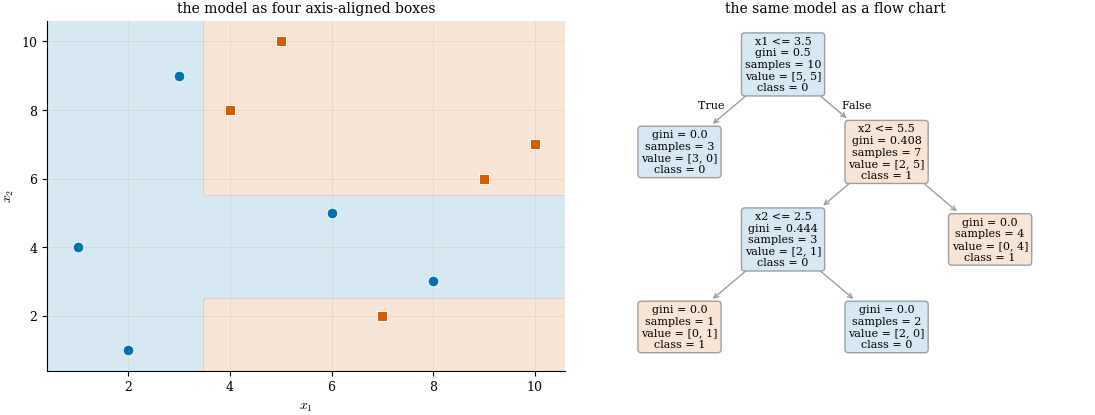

point x = (6, 5) visits nodes [0, 2, 3, 5]:
   node 0: x1 = 6 >  3.5  ->  go right
   node 2: x2 = 5 <= 5.5  ->  go left
   node 3: x2 = 5 >  2.5  ->  go right
   node 5 is a leaf -> predict class 0, P(y = 1 | x) = 0.00


In [2]:
print("Lecture 08's ten points (class 0 = circles, class 1 = squares)")
print("   i   x1    x2    y")
for i, ((a, b), lab) in enumerate(zip(X10, y10)):
    print(f"  {i:2d}  {a:4.0f}  {b:4.0f}    {lab}")
print(f"\n{len(y10)} points, {X10.shape[1]} features, class counts {np.bincount(y10)}")

tree10 = DecisionTreeClassifier(random_state=0).fit(X10, y10)
print("\n" + export_text(tree10, feature_names=["x1", "x2"]))
print(f"{tree10.get_n_leaves()} leaves, depth {tree10.get_depth()}, "
      f"training accuracy {tree10.score(X10, y10):.2f}")
print("thresholds the greedy search chose:",
      [f"{t:.1f}" for t in tree10.tree_.threshold if t != -2.0])
lin10 = LogisticRegression(C=1e6, max_iter=200_000).fit(X10, y10)      # a straight line, for scale
print(f"a nearly unregularized LINEAR model reaches only {lin10.score(X10, y10):.2f} on the same "
      f"points:\nif a separating line existed, this fit would have found it.")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.2))
draw_boxes(a1, tree10, X10, y10)
a1.set_title("the model as four axis-aligned boxes", fontsize=10)
drawn = plot_tree(tree10, ax=a2, feature_names=["x1", "x2"], class_names=["0", "1"],
                  filled=True, rounded=True, fontsize=8, precision=3)
# Recolor the nodes onto our palette. The fill has to stay OPAQUE: plot_tree aims every edge
# at the CENTER of the parent box and counts on the box being painted over it, so a
# translucent fill lets the edge show through the node's own "value = ..." and "class = ...".
for ann in drawn:
    txt, patch = ann.get_text(), ann.get_bbox_patch()
    if patch is not None and "value = [" in txt:
        counts = [float(v) for v in txt.split("value = [")[1].split("]")[0].split(",")]
        patch.set(facecolor=FILL[int(np.argmax(counts))], edgecolor=CX)
    if ann.arrow_patch is not None:          # plot_tree draws these black by default
        ann.arrow_patch.set(color=CX)
a2.set_title("the same model as a flow chart", fontsize=10)
plt.show()

# a path from the root to a leaf is an AND of inequalities -- read one aloud
i_pt, t10 = 3, tree10.tree_
visited = list(map(int, tree10.decision_path(X10[[i_pt]]).indices))
print(f"point x = ({X10[i_pt, 0]:.0f}, {X10[i_pt, 1]:.0f}) visits nodes {visited}:")
for nd in visited:
    if t10.children_left[nd] == -1:
        print(f"   node {nd} is a leaf -> predict class {tree10.predict(X10[[i_pt]])[0]}, "
              f"P(y = 1 | x) = {tree10.predict_proba(X10[[i_pt]])[0, 1]:.2f}")
    else:
        j, thr = int(t10.feature[nd]), float(t10.threshold[nd])
        v = X10[i_pt, j]
        print(f"   node {nd}: x{j + 1} = {v:.0f} {'<=' if v <= thr else '> '} {thr:.1f}"
              f"  ->  go {'left' if v <= thr else 'right'}")

## 2. Impurity is the cost of the best constant

A leaf sees only its own labels, so its prediction is whichever single constant minimizes the
loss there: the **majority class** under 0/1 loss, the **mean** under squared loss, the observed
frequency $\hat p$ under log-loss. **Impurity is the value of that minimum**, which is why the
three standard measures are not arbitrary formulas:

$$\mathrm{Gini}(m)=1-\sum_k \hat p_{mk}^2,\qquad
H(m)=-\sum_k \hat p_{mk}\log_2 \hat p_{mk},\qquad
\mathrm{err}(m)=1-\max_k \hat p_{mk}.$$

A split $(j,t)$ is scored by its **information gain**: the parent's impurity minus the
**size-weighted** impurity of the two children,

$$\Delta I(j,t)=I(m)-\frac{n_L}{n_m}I(L)-\frac{n_R}{n_m}I(R).$$

The cell below checks our three-line `gini()` against the impurities scikit-learn already stored
in `tree_.impurity`, reproduces the root's gain, and then asks all three criteria to score one
particular split of node $B$ &mdash; the one that hands us a perfectly pure leaf.

node                   n   [n0,n1]  our Gini   sklearn  entropy   error
root (all 10)         10    [5, 5]  0.500000  0.500000   1.0000  0.5000
B  (x1 > 3.5)          7    [2, 5]  0.408163  0.408163   0.8631  0.2857
D  (and x2 <= 5.5)     3    [2, 1]  0.444444  0.444444   0.9183  0.3333

largest |our Gini - sklearn's tree_.impurity| = 0.0e+00
exact fractions: root 1/2, node B 20/49 = 0.408163, node D 4/9 = 0.444444

gain of the root split x1 <= 3.5:  0.5000 - (3/10)(0.0000) - (7/10)(0.4082) = 0.214286 = 3/14 = 0.214286

node B [2, 5]  ->  left (x2 <= 6.5) [2, 2], right [0, 3]   <- a PURE leaf appears

criterion     parent   weighted children       gain
Gini          0.4082              0.2857   0.122449
entropy       0.8631              0.5714   0.291692
error         0.2857              0.2857   0.000000

Gini gain = 6/49 = 0.122449;  entropy gain = 0.291692;  error-rate gain = 0.000000


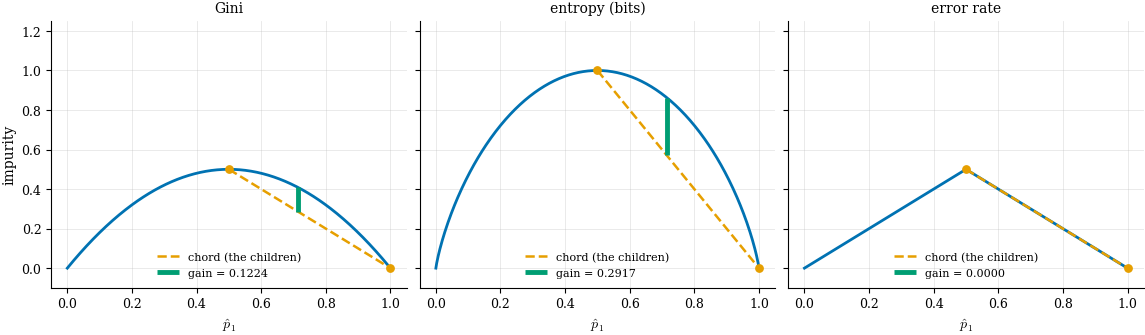

The error rate is a straight line on each half, so the chord lies ON the curve.
A grower scoring with the error rate would reject this split and stop.


In [3]:
nodes_imp = {"root (all 10)": (np.ones(10, bool), 0),
             "B  (x1 > 3.5)": (X10[:, 0] > 3.5, 2),
             "D  (and x2 <= 5.5)": ((X10[:, 0] > 3.5) & (X10[:, 1] <= 5.5), 3)}

print(f"{'node':20s} {'n':>3s} {'[n0,n1]':>9s} {'our Gini':>9s} {'sklearn':>9s} "
      f"{'entropy':>8s} {'error':>7s}")
worst_imp = 0.0
for name, (m_imp, nd) in nodes_imp.items():
    ym = y10[m_imp]
    worst_imp = max(worst_imp, abs(gini(ym) - t10.impurity[nd]))
    print(f"{name:20s} {m_imp.sum():3d} {str(list(map(int, np.bincount(ym, minlength=2)))):>9s} "
          f"{gini(ym):9.6f} {t10.impurity[nd]:9.6f} {entropy(ym):8.4f} {error(ym):7.4f}")
print(f"\nlargest |our Gini - sklearn's tree_.impurity| = {worst_imp:.1e}")
print(f"exact fractions: root 1/2, node B 20/49 = {20/49:.6f}, node D 4/9 = {4/9:.6f}")
print(f"\ngain of the root split x1 <= 3.5:  {gini(y10):.4f} - (3/10)(0.0000) "
      f"- (7/10)({20/49:.4f}) = {gain(X10, y10, 0, 3.5):.6f} = 3/14 = {3/14:.6f}")

# --- node B cut at x2 <= 6.5 hands us a PURE leaf. What does each criterion say? ---
mB_imp = X10[:, 0] > 3.5
XB_imp, yB_imp = X10[mB_imp], y10[mB_imp]
left_imp = XB_imp[:, 1] <= 6.5
cnt = lambda v: list(map(int, np.bincount(v, minlength=2)))
print(f"\nnode B {cnt(yB_imp)}  ->  left (x2 <= 6.5) {cnt(yB_imp[left_imp])}, "
      f"right {cnt(yB_imp[~left_imp])}   <- a PURE leaf appears")
print(f"\n{'criterion':10s} {'parent':>9s} {'weighted children':>19s} {'gain':>10s}")
for nm, imp in (("Gini", gini), ("entropy", entropy), ("error", error)):
    par = imp(yB_imp)
    ch = 4 / 7 * imp(yB_imp[left_imp]) + 3 / 7 * imp(yB_imp[~left_imp])
    print(f"{nm:10s} {par:9.4f} {ch:19.4f} {par - ch:10.6f}")
print(f"\nGini gain = 6/49 = {6/49:.6f};  entropy gain = "
      f"{gain(XB_imp, yB_imp, 1, 6.5, entropy):.6f};  error-rate gain = "
      f"{gain(XB_imp, yB_imp, 1, 6.5, error):.6f}")

# why: impurity is concave, and the gain is the gap between the curve and the chord
safe = lambda q: np.clip(np.asarray(q, dtype=float), 1e-12, 1 - 1e-12)
f_imp = {"Gini": lambda q: 1 - safe(q) ** 2 - (1 - safe(q)) ** 2,
         "entropy (bits)": lambda q: -(safe(q) * np.log2(safe(q))
                                       + (1 - safe(q)) * np.log2(1 - safe(q))),
         "error rate": lambda q: np.minimum(safe(q), 1 - safe(q))}
p_grid = np.linspace(0.0, 1.0, 400)
pL, pR, wL = 0.5, 1.0, 4 / 7            # the two children's class-1 rates, and the left weight
pPar = wL * pL + (1 - wL) * pR          # = 5/7, the parent's rate: a MIXTURE of the children's

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4), sharey=True)
for ax, (nm, f) in zip(axes, f_imp.items()):
    chord = wL * f(pL) + (1 - wL) * f(pR)
    g_fig = np.round(float(f(pPar) - chord), 6) + 0.0        # + 0.0 turns -0.0 into 0.0
    ax.plot(p_grid, f(p_grid), color=C0, lw=2)
    ax.plot([pL, pR], [f(pL), f(pR)], "--", color=CN, lw=1.8, label="chord (the children)")
    ax.vlines(pPar, chord, f(pPar), color=CG, lw=3.5, label=f"gain = {g_fig:.4f}")
    ax.scatter([pL, pR], [f(pL), f(pR)], color=CN, zorder=4, s=28)
    ax.set_title(nm, fontsize=10)
    ax.set_xlabel(r"$\hat p_1$")
    ax.legend(fontsize=8, loc="lower center")
axes[0].set_ylabel("impurity")
axes[0].set_ylim(-0.1, 1.25)
plt.show()
print("The error rate is a straight line on each half, so the chord lies ON the curve.")
print("A grower scoring with the error rate would reject this split and stop.")

The error rate scored a split that produces a **perfectly pure leaf** at exactly zero. The figure
says why: the parent's class fraction is a *mixture* of the children's, so the weighted child
impurity is the **chord**, and the gain is the gap between curve and chord. Gini and entropy are
strictly concave, so that gap is positive; the error rate is piecewise **linear**, so the chord
lies on the curve. **Grow with Gini or entropy**, and keep the error rate for *evaluating* a
finished tree.

## 3. Finding the best split &mdash; and what a split can see

The threshold $t$ is continuous, so there are infinitely many candidate splits &mdash; but only
finitely many distinct **partitions**. Two thresholds between the same pair of sorted values give
the identical split, so we sort each feature and test only the **midpoints of consecutive
distinct values**: at most $n-1$ candidates per feature. The gain is a **step function** of $t$;
there is nothing to differentiate, so we enumerate.

That also settles a question left over from every previous session. A split only ever compares a
feature to a threshold, so a tree sees **only the order** of each feature's values. Any increasing
transform &mdash; $\log$, standardization, a change of units &mdash; leaves the tree unchanged. A
**rotation** is not an increasing transform of any single feature, and it is not free.

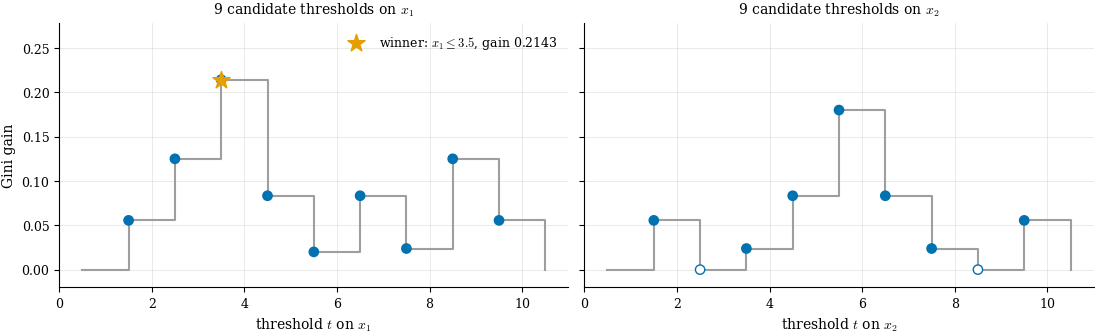

18 candidate splits in total; the best four:
   x1 <=  3.5   gain 0.214286
   x2 <=  5.5   gain 0.180000
   x1 <=  2.5   gain 0.125000
   x1 <=  8.5   gain 0.125000
candidates worth exactly zero (the hollow circles): 2 -- x2 <= 2.5, x2 <= 8.5

ours: x1 <= 3.5   |   sklearn's root: x1 <= 3.5   ->   same split: True

features                 leaves  train   same partition of the 10 points?
original x1, x2               4   1.00   True
log(x1), x2                   4   1.00   True
standardized                  4   1.00   True
rotated by 30 degrees         6   1.00   False

only the printed threshold moves: x1 <= 3.5 becomes log(x1) <= 1.2425, and exp(1.2425) = 3.4641 = sqrt(12) = 3.4641
-- the geometric midpoint of 3 and 4 instead of the arithmetic one. So a tree needs
NO standardization: it is the one model in this course that is scale-free.
rotate by  10 degrees -> 4 leaves
rotate by  20 degrees -> 5 leaves
rotate by  30 degrees -> 6 leaves
rotate by  45 degrees -> 6 leaves
rotate by  6

In [4]:
scan_sc = {j: (midpoints(X10[:, j]),
               np.array([gain(X10, y10, j, t) for t in midpoints(X10[:, j])]))
           for j in (0, 1)}
cands_sc = [(j, t, g) for j in (0, 1) for t, g in zip(*scan_sc[j])]
j_star, t_star, g_star = max(cands_sc, key=lambda c: c[2])

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.4), sharey=True)
for ax, j in zip(axes, (0, 1)):
    ts, gs = scan_sc[j]
    ax.step(np.r_[ts[0] - 1, ts, ts[-1] + 1], np.r_[0, gs, 0], where="post", color=CX)
    ax.scatter(ts, gs, s=45, color=np.where(gs > 1e-12, C0, "white"), edgecolor=C0, zorder=3)
    if j == j_star:
        ax.scatter([t_star], [g_star], s=170, marker="*", color=CN, zorder=4, clip_on=False,
                   label=f"winner: $x_{j+1} \\leq {t_star}$, gain {g_star:.4f}")
        ax.legend(fontsize=9, loc="upper right")
    ax.set_xlabel(f"threshold $t$ on $x_{j+1}$")
    ax.set_title(f"{len(ts)} candidate thresholds on $x_{j+1}$", fontsize=10)
axes[0].set_ylabel("Gini gain")
axes[0].set_ylim(-0.02, 1.30 * g_star)             # headroom: do not slice the winner star
plt.show()

print(f"{len(cands_sc)} candidate splits in total; the best four:")
for j, t, g in sorted(cands_sc, key=lambda c: -c[2])[:4]:
    print(f"   x{j+1} <= {t:4.1f}   gain {g:.6f}")
zeros_sc = [f"x{j+1} <= {t:.1f}" for j, t, g in cands_sc if abs(g) < 1e-12]
print(f"candidates worth exactly zero (the hollow circles): {len(zeros_sc)} "
      f"-- {', '.join(zeros_sc)}")
print(f"\nours: x{j_star+1} <= {t_star}   |   sklearn's root: x{int(t10.feature[0])+1} "
      f"<= {t10.threshold[0]}   ->   same split: "
      f"{(j_star, t_star) == (int(t10.feature[0]), float(t10.threshold[0]))}")

# --- a split compares a feature to a threshold, so only its ORDER matters ----
part_of = lambda clf, Xv: tuple(np.unique(clf.apply(Xv), return_inverse=True)[1])
ang = np.deg2rad(30.0)
R30 = np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]])
variants = (("original x1, x2", X10),
            ("log(x1), x2", np.column_stack([np.log(X10[:, 0]), X10[:, 1]])),
            ("standardized", (X10 - X10.mean(0)) / X10.std(0)),
            ("rotated by 30 degrees", X10 @ R30.T))

print(f"\n{'features':24s} {'leaves':>6s} {'train':>6s}   same partition of the 10 points?")
for name, Xv in variants:
    c_sc = DecisionTreeClassifier(random_state=0).fit(Xv, y10)
    print(f"{name:24s} {c_sc.get_n_leaves():6d} {c_sc.score(Xv, y10):6.2f}   "
          f"{part_of(c_sc, Xv) == part_of(tree10, X10)}")

log_t = DecisionTreeClassifier(random_state=0).fit(variants[1][1], y10).tree_.threshold[0]
print(f"\nonly the printed threshold moves: x1 <= {t10.threshold[0]:.1f} becomes "
      f"log(x1) <= {log_t:.4f}, and exp({log_t:.4f}) = {np.exp(log_t):.4f} = sqrt(12) = "
      f"{np.sqrt(12):.4f}")
print("-- the geometric midpoint of 3 and 4 instead of the arithmetic one. So a tree needs")
print("NO standardization: it is the one model in this course that is scale-free.")
for deg in (10, 20, 30, 45, 60):
    a_rot = np.deg2rad(deg)
    Rr = np.array([[np.cos(a_rot), -np.sin(a_rot)], [np.sin(a_rot), np.cos(a_rot)]])
    print(f"rotate by {deg:3d} degrees -> "
          f"{DecisionTreeClassifier(random_state=0).fit(X10 @ Rr.T, y10).get_n_leaves()} leaves")

## 4. Greedy is short-sighted: the XOR failure

Every split above was chosen by **one-step lookahead**: take the best cut *now*, then recurse.
That is the only tractable thing to do &mdash; finding the smallest optimal tree is NP-hard &mdash;
but it has a failure mode, and XOR is the cleanest example of it.

In XOR the classes sit on opposite corners. Cut anywhere and each child keeps the parent's class
proportions exactly, so **every candidate split at the root scores a gain of zero**. A grower that
stops when the gain is small (`min_impurity_decrease`) therefore stops at the root with one leaf
and 50% accuracy &mdash; even though a depth-2 tree is perfect. The useless-looking split is the one
that makes the *next* split perfect.

This is the argument for **growing first and pruning after**, which is section&nbsp;7. It is also
the first appearance of a problem that returns twice: Session&nbsp;09's boosted stumps hit the same
wall (an additive model of axis-aligned stumps cannot represent XOR either), and Session&nbsp;12
solves it with a hidden layer.

the four XOR corners (x1, x2 -> y): [(0, 0, 0), (0, 1, 1), (1, 0, 1), (1, 1, 0)]
   root candidate  x1 <= 0.5:   Gini gain = 0.000000
   root candidate  x2 <= 0.5:   Gini gain = 0.000000
min_impurity_decrease = 1e-09 -> 1 leaf,   accuracy 0.50
max_depth = 2               -> 4 leaves, accuracy 1.00

200 points: the largest |gain| over ALL 198 root candidates is 5.6e-17 -- floating-point zero
min_impurity_decrease = 0.01     -> 1 leaf,   accuracy 0.50
greedy max_depth = 2             -> 4 leaves, accuracy 0.51   (it broke the all-zero tie at x2 <= -1.69)
the RIGHT depth-2 tree, by hand  -> 4 leaves, accuracy 1.00   (x1 <= 0, then x2 <= 0)
grown out, then judged later     -> 12 leaves, accuracy 1.00

over 10 fresh samples: greedy depth 2 reaches 0.5115 on average (min 0.510, max 0.520),
while growing out reaches 1.0000 every time -- the failure is the recipe, not the sample.


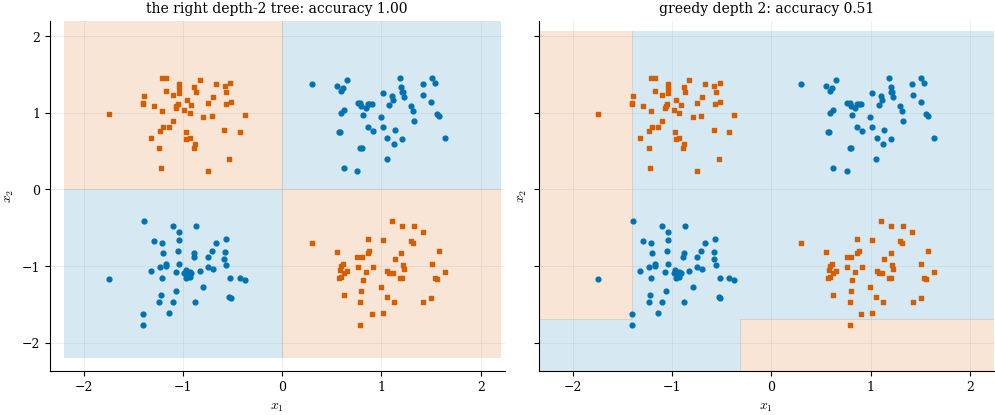

In [5]:
# (a) the four exact corners -- both candidate root splits have gain exactly zero
Xx4, yx4 = make_xor()
print("the four XOR corners (x1, x2 -> y):",
      [(int(a), int(b), int(c)) for (a, b), c in zip(Xx4, yx4)])
for j in (0, 1):
    for t in midpoints(Xx4[:, j]):
        print(f"   root candidate  x{j+1} <= {t:.1f}:   Gini gain = "
              f"{gain(Xx4, yx4, j, t):.6f}")
EPS = 1e-9                                                    # <-- CHANGE ME
stop4 = DecisionTreeClassifier(min_impurity_decrease=EPS, random_state=0).fit(Xx4, yx4)
deep4 = DecisionTreeClassifier(max_depth=2, random_state=0).fit(Xx4, yx4)
print(f"min_impurity_decrease = {EPS:g} -> {stop4.get_n_leaves()} leaf,   "
      f"accuracy {stop4.score(Xx4, yx4):.2f}")
print(f"max_depth = 2               -> {deep4.get_n_leaves()} leaves, "
      f"accuracy {deep4.score(Xx4, yx4):.2f}")


# (b) 200 noisy points with the same structure, built so the zero stays exact:
#     the two clusters of a column share their x1 offsets, those of a row their x2 offsets
def xor_cloud(m=50, seed=0):
    "four Gaussian clusters on the XOR corners, with every root gain exactly zero"
    rng_x = np.random.default_rng(seed)
    off = lambda: np.clip(rng_x.normal(0, 0.32, m), -0.85, 0.85)   # never crosses 0
    oxL, oxR, oyT, oyB = off(), off(), off(), off()
    Xc = np.vstack([np.column_stack(c) for c in ((-1 + oxL, 1 + oyT), (1 + oxR, 1 + oyT),
                                                 (-1 + oxL, -1 + oyB), (1 + oxR, -1 + oyB))])
    return Xc, np.concatenate([np.full(m, k) for k in (1, 0, 0, 1)])


Xxc, yxc = xor_cloud()
n_cand_x = sum(len(midpoints(Xxc[:, j])) for j in (0, 1))
worst_x = max(max(abs(gain(Xxc, yxc, j, t)) for t in midpoints(Xxc[:, j])) for j in (0, 1))
print(f"\n{len(yxc)} points: the largest |gain| over ALL {n_cand_x} root candidates is "
      f"{worst_x:.1e} -- floating-point zero")

stop_x = DecisionTreeClassifier(min_impurity_decrease=0.01, random_state=0).fit(Xxc, yxc)
greedy2_x = DecisionTreeClassifier(max_depth=2, random_state=0).fit(Xxc, yxc)
grown_x = DecisionTreeClassifier(random_state=0).fit(Xxc, yxc)
hand_x = (Xxc[:, 0] > 0).astype(int) ^ (Xxc[:, 1] > 0).astype(int)
print(f"min_impurity_decrease = 0.01     -> {stop_x.get_n_leaves()} leaf,   "
      f"accuracy {stop_x.score(Xxc, yxc):.2f}")
print(f"greedy max_depth = 2             -> {greedy2_x.get_n_leaves()} leaves, "
      f"accuracy {greedy2_x.score(Xxc, yxc):.2f}   (it broke the all-zero tie at "
      f"x{int(greedy2_x.tree_.feature[0])+1} <= {greedy2_x.tree_.threshold[0]:.2f})")
print(f"the RIGHT depth-2 tree, by hand  -> 4 leaves, accuracy "
      f"{(hand_x == yxc).mean():.2f}   (x1 <= 0, then x2 <= 0)")
print(f"grown out, then judged later     -> {grown_x.get_n_leaves()} leaves, "
      f"accuracy {grown_x.score(Xxc, yxc):.2f}")

acc2_x, accg_x = [], []
for s in range(10):
    Xs, ys = xor_cloud(seed=s)
    acc2_x.append(DecisionTreeClassifier(max_depth=2, random_state=0).fit(Xs, ys).score(Xs, ys))
    accg_x.append(DecisionTreeClassifier(random_state=0).fit(Xs, ys).score(Xs, ys))
print(f"\nover 10 fresh samples: greedy depth 2 reaches {np.mean(acc2_x):.4f} on average "
      f"(min {np.min(acc2_x):.3f}, max {np.max(acc2_x):.3f}),")
print(f"while growing out reaches {np.mean(accg_x):.4f} every time -- the failure is the "
      f"recipe, not the sample.")

gx_x, gy_x = np.meshgrid(np.linspace(-2.2, 2.2, 300), np.linspace(-2.2, 2.2, 300))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.0, 4.2), sharex=True, sharey=True)
a1.contourf(gx_x, gy_x, ((gx_x > 0).astype(int) ^ (gy_x > 0).astype(int)),
            levels=[-0.5, 0.5, 1.5], colors=BOX, zorder=0)
a1.set_title(f"the right depth-2 tree: accuracy {(hand_x == yxc).mean():.2f}", fontsize=10)
draw_boxes(a2, greedy2_x, Xxc, yxc, s=12)
a2.set_title(f"greedy depth 2: accuracy {greedy2_x.score(Xxc, yxc):.2f}", fontsize=10)
for ax in (a1, a2):
    ax.scatter(*Xxc[yxc == 0].T, s=12, marker="o", color=C0, zorder=3)
    ax.scatter(*Xxc[yxc == 1].T, s=12, marker="s", color=C1, zorder=3)
    ax.set_xlabel("$x_1$")
    ax.grid(alpha=0.25)
a1.set_ylabel("$x_2$")
plt.show()

## 5. Tree size *is* the complexity knob

$|T|$, the number of leaves, plays the role $\lambda$ played for ridge and $(C,\gamma)$ played for
the SVM. A shallow tree has few boxes and underfits; a fully grown tree puts a box around
(almost) every training point and has memorized the noise.

> &#9888;&#65039; With default settings `DecisionTreeClassifier` grows until every leaf is pure.
> A tree is **overfitted by default** &mdash; the one model in this course where doing nothing is
> actively wrong.

We sweep `max_leaf_nodes` on 300 two-moons points (the lecture's dataset: `noise=0.32`,
`random_state=0`, a 60/40 split) and score each size three ways: on the training set, by 5-fold
cross-validation *inside* the training set, and &mdash; shown only for honesty &mdash; on the test set.
Everything printed here describes **this one split**; section&nbsp;7 repeats the comparison over
fifteen splits, and the answer changes.

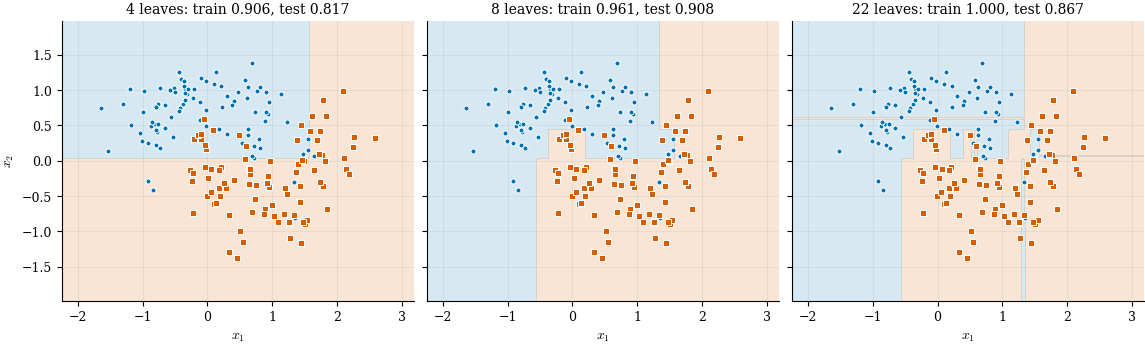

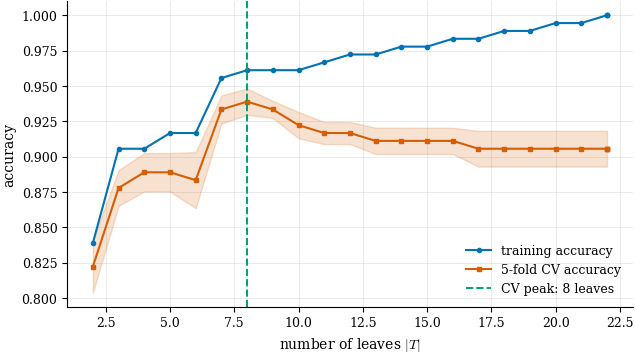

training accuracy is monotone in |T|: True  <- so it can never choose the size
CV peaks at 8 leaves with 0.9389 (test there: 0.9083)
fully grown (sklearn's defaults): 22 leaves, train 1.0000, test 0.8667

On THIS split, growing from 8 to 22 leaves buys +0.0389 training accuracy
and -0.0417 test accuracy.


In [6]:
Xmn, ymn = make_moons(n_samples=300, noise=0.32, random_state=0)        # the lecture's data
Xtr_mn, Xte_mn, ytr_mn, yte_mn = train_test_split(Xmn, ymn, test_size=0.4, random_state=0,
                                                  stratify=ymn)
cv_mn = StratifiedKFold(5, shuffle=True, random_state=0)

rows_mn = []
for L in np.arange(2, 25):
    c_mn = DecisionTreeClassifier(max_leaf_nodes=L, random_state=0)
    s_mn = cross_val_score(c_mn, Xtr_mn, ytr_mn, cv=cv_mn)
    c_mn.fit(Xtr_mn, ytr_mn)
    rows_mn.append((c_mn.get_n_leaves(), c_mn.score(Xtr_mn, ytr_mn), s_mn.mean(),
                    s_mn.std() / np.sqrt(5), c_mn.score(Xte_mn, yte_mn)))
rows_mn = np.array(rows_mn)
full_mn = DecisionTreeClassifier(random_state=0).fit(Xtr_mn, ytr_mn)
best_mn = int(np.argmax(rows_mn[:, 2]))

panels_mn = [DecisionTreeClassifier(max_leaf_nodes=L, random_state=0).fit(Xtr_mn, ytr_mn)
             for L in (4, 8)] + [full_mn]                               # <-- CHANGE ME
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.5), sharex=True, sharey=True)
for ax, c_mn in zip(axes, panels_mn):
    draw_boxes(ax, c_mn, Xtr_mn, ytr_mn, s=13)
    ax.set_title(f"{c_mn.get_n_leaves()} leaves: train {c_mn.score(Xtr_mn, ytr_mn):.3f}, "
                 f"test {c_mn.score(Xte_mn, yte_mn):.3f}", fontsize=10)
for ax in axes[1:]:
    ax.set_ylabel("")                    # shared axes: label the left panel only
plt.show()

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(rows_mn[:, 0], rows_mn[:, 1], "-o", ms=3, color=C0, label="training accuracy")
ax.plot(rows_mn[:, 0], rows_mn[:, 2], "-s", ms=3, color=C1, label="5-fold CV accuracy")
ax.fill_between(rows_mn[:, 0], rows_mn[:, 2] - rows_mn[:, 3], rows_mn[:, 2] + rows_mn[:, 3],
                color=C1, alpha=0.18)
ax.axvline(rows_mn[best_mn, 0], color=CG, ls="--", lw=1.4,
           label=f"CV peak: {rows_mn[best_mn, 0]:.0f} leaves")
ax.set_xlabel("number of leaves $|T|$")
ax.set_ylabel("accuracy")
ax.legend(fontsize=9, loc="lower right")
plt.show()

print(f"training accuracy is monotone in |T|: "
      f"{bool(np.all(np.diff(rows_mn[:, 1]) >= -1e-12))}  <- so it can never choose the size")
print(f"CV peaks at {rows_mn[best_mn, 0]:.0f} leaves with {rows_mn[best_mn, 2]:.4f} "
      f"(test there: {rows_mn[best_mn, 4]:.4f})")
print(f"fully grown (sklearn's defaults): {full_mn.get_n_leaves()} leaves, "
      f"train {full_mn.score(Xtr_mn, ytr_mn):.4f}, test {full_mn.score(Xte_mn, yte_mn):.4f}")
print(f"\nOn THIS split, growing from {rows_mn[best_mn, 0]:.0f} to {full_mn.get_n_leaves()} "
      f"leaves buys {full_mn.score(Xtr_mn, ytr_mn) - rows_mn[best_mn, 1]:+.4f} training accuracy")
print(f"and {full_mn.score(Xte_mn, yte_mn) - rows_mn[best_mn, 4]:+.4f} test accuracy.")

## 6. Regression trees: the same algorithm, one substitution

Swap "majority class" for "the mean" and "Gini" for the **sum of squared errors**
$\mathrm{SSE}(m)=\sum_{i\in m}(y_i-\bar y_m)^2$, and classification becomes regression.
Everything else &mdash; the midpoint scan, the greedy recursion, the pruning &mdash; is unchanged.

The lecture's example: eight apartments, area $1,\dots,8$ (tens of m$^2$) against rent
$2,3,4,5,10,11,12,13$ (hundreds of EUR). One leaf predicts $\bar y=7.5$ with SSE $138$. We scan
all seven thresholds by hand, then confirm that scikit-learn picks the same one.

> &#9888;&#65039; **Unit gotcha.** `tree_.impurity` for a regressor is the **mean** squared error
> in the node, not the sum. Multiply by $n_m$ to get the lecture's SSE.

A regression tree is a **staircase**: it cannot slope, only step. The consequence shows up at the
end of the cell &mdash; outside the training range its prediction is flat forever.

one leaf: predict the mean 7.5, SSE = 138

 threshold  left mean  right mean  SSE(L)+SSE(R)     gain
       1.5       2.00        8.29         103.43    34.57
       2.5       2.50        9.17          71.33    66.67
       3.5       3.00       10.20          40.80    97.20
       4.5       3.50       11.50          10.00   128.00
       5.5       4.80       12.00          40.80    97.20
       6.5       5.83       12.50          71.33    66.67
       7.5       6.71       13.00         103.43    34.57

sklearn's stump splits at area <= 4.5 and predicts [ 3.5 11.5]
its root impurity is the MEAN squared error, not the sum: 17.2500 x 8 = 138.0 = our SSE


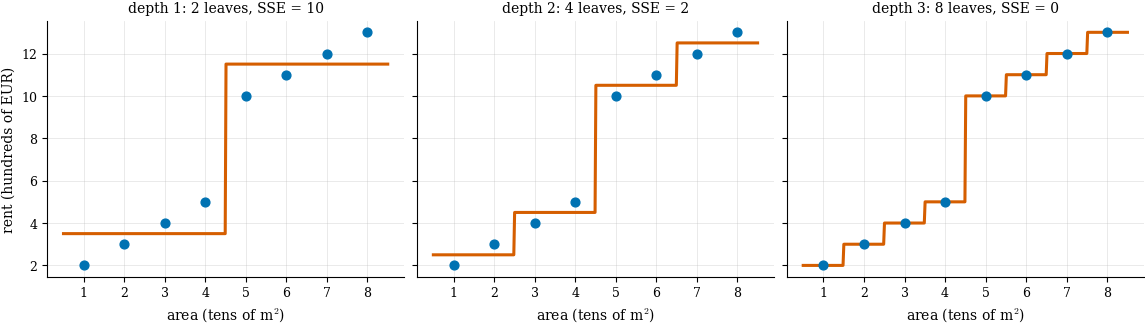

    area    stump   depth-3 tree   straight line
     8.0    11.50          13.00           13.67
    12.0    11.50          13.00           20.71
   100.0    11.50          13.00          175.76
The tree repeats its right-most leaf forever; only the line keeps climbing.


In [7]:
area_rt, rent_rt = make_rent8()            # the lecture's eight apartments
A_rt = area_rt[:, None]
sse = lambda v: float(((v - v.mean()) ** 2).sum())

print(f"one leaf: predict the mean {rent_rt.mean():.1f}, SSE = {sse(rent_rt):.0f}")
print(f"\n{'threshold':>10s} {'left mean':>10s} {'right mean':>11s} {'SSE(L)+SSE(R)':>14s} "
      f"{'gain':>8s}")
for t in midpoints(area_rt):
    Lv, Rv = rent_rt[area_rt <= t], rent_rt[area_rt > t]
    print(f"{t:10.1f} {Lv.mean():10.2f} {Rv.mean():11.2f} {sse(Lv) + sse(Rv):14.2f} "
          f"{sse(rent_rt) - sse(Lv) - sse(Rv):8.2f}")

stump_rt = DecisionTreeRegressor(max_depth=1, random_state=0).fit(A_rt, rent_rt)
print(f"\nsklearn's stump splits at area <= {stump_rt.tree_.threshold[0]:.1f} and predicts "
      f"{np.sort(stump_rt.tree_.value[1:, 0, 0])}")
print(f"its root impurity is the MEAN squared error, not the sum: "
      f"{stump_rt.tree_.impurity[0]:.4f} x {len(rent_rt)} = "
      f"{stump_rt.tree_.impurity[0] * len(rent_rt):.1f} = our SSE")

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.3), sharey=True)
xs_rt = np.linspace(0.5, 8.5, 400)[:, None]
for ax, d in zip(axes, (1, 2, 3)):                                      # <-- CHANGE ME
    r_rt = DecisionTreeRegressor(max_depth=d, random_state=0).fit(A_rt, rent_rt)
    ax.scatter(area_rt, rent_rt, s=40, color=C0, zorder=3)
    ax.plot(xs_rt, r_rt.predict(xs_rt), color=C1, lw=2.2)
    ax.set_title(f"depth {d}: {r_rt.get_n_leaves()} leaves, "
                 f"SSE = {((rent_rt - r_rt.predict(A_rt)) ** 2).sum():.0f}", fontsize=10)
    ax.set_xlabel("area (tens of m$^2$)")
axes[0].set_ylabel("rent (hundreds of EUR)")
plt.show()

# a tree cannot extrapolate: outside the training range every leaf is already fixed
deep3_rt = DecisionTreeRegressor(max_depth=3, random_state=0).fit(A_rt, rent_rt)
slope_rt, icpt_rt = np.polyfit(area_rt, rent_rt, 1)
print(f"{'area':>8s} {'stump':>8s} {'depth-3 tree':>14s} {'straight line':>15s}")
for q in (8.0, 12.0, 100.0):
    print(f"{q:8.1f} {stump_rt.predict([[q]])[0]:8.2f} {deep3_rt.predict([[q]])[0]:14.2f} "
          f"{slope_rt * q + icpt_rt:15.2f}")
print("The tree repeats its right-most leaf forever; only the line keeps climbing.")

## 7. Cost-complexity pruning

Pre-pruning (`max_depth`, `min_samples_leaf`, `min_impurity_decrease`) is cheap but
short-sighted &mdash; section&nbsp;4 showed it stopping at the root on XOR. **Post-pruning** grows the
tree fully, then collapses the subtrees that do not earn their keep, judging each one with the
whole tree in view. The objective is the familiar regularized one,

$$R_\alpha(T)=R(T)+\alpha|T|,\qquad
R(T)=\sum_{m\,\in\,\text{leaves}}\frac{n_m}{n}\,I(m),$$

with $\alpha$ a **price per leaf**. Collapsing the subtree $T_m$ below node $m$ raises the risk by
$R(m)-R(T_m)$ and saves $|T_m|-1$ leaves, so it becomes worthwhile as soon as $\alpha$ passes the
**break-even price**

$$g(m)=\frac{R(m)-R(T_m)}{|T_m|-1}.$$

Repeatedly collapsing the **weakest link** (the smallest $g$) traces a finite nested sequence of
subtrees, so although $\alpha$ is continuous, only finitely many trees can ever be optimal.
`cost_complexity_pruning_path` returns exactly those breakpoints; on the ten points there are
four, and we rederive the three non-zero ones by hand.

     alpha  |T|      R(T)   R(T) + alpha |T|
  0.000000    4  0.000000           0.000000
  0.133333    3  0.133333           0.533333
  0.152381    2  0.285714           0.590476
  0.214286    1  0.500000           0.714286

sklearn's breakpoints  : [0.       0.133333 0.152381 0.214286]
the lecture's fractions: [0.       0.133333 0.152381 0.214286]   identical: True

 node      R(m)    R(T_m)  |T_m|       g(m)   why
    D  0.133333  0.000000      2   0.133333   its two children are pure
    B  0.285714  0.133333      2   0.152381   D is now a leaf
 root  0.500000  0.285714      2   0.214286   B is now a leaf
by hand: 0.133333, 0.152381, 0.214286  = 2/15, 16/105, 3/14


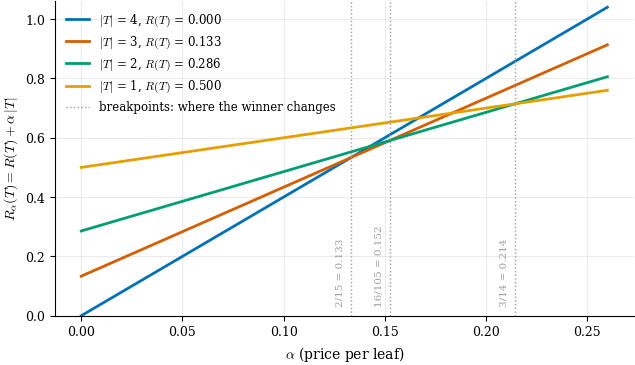

Each subtree's cost is a straight line in alpha, and the winner is the lowest one.
Only these 4 trees can ever be optimal, so alpha is chosen from a SHORT LIST.


In [8]:
def risk(clf, X, y):
    "R(T) = sum over leaves of (n_m / n) * Gini(m) -- the training risk, in Gini units"
    leaf = clf.apply(X)
    return sum(len(y[leaf == m_]) / len(y) * gini(y[leaf == m_]) for m_ in np.unique(leaf))


path10 = tree10.cost_complexity_pruning_path(X10, y10)
subtrees10 = [DecisionTreeClassifier(random_state=0, ccp_alpha=a).fit(X10, y10)
              for a in path10.ccp_alphas]
print(f"{'alpha':>10s} {'|T|':>4s} {'R(T)':>9s} {'R(T) + alpha |T|':>18s}")
for a, c_p in zip(path10.ccp_alphas, subtrees10):
    print(f"{a:10.6f} {c_p.get_n_leaves():4d} {risk(c_p, X10, y10):9.6f} "
          f"{risk(c_p, X10, y10) + a * c_p.get_n_leaves():18.6f}")
print(f"\nsklearn's breakpoints  : {np.round(path10.ccp_alphas, 6)}")
print(f"the lecture's fractions: {np.round([0, 2/15, 16/105, 3/14], 6)}   identical: "
      f"{np.allclose(path10.ccp_alphas, [0, 2/15, 16/105, 3/14])}")

# the weakest link, by hand, three times: collapse D, then B, then the root
mB_cc = X10[:, 0] > 3.5
mD_cc = mB_cc & (X10[:, 1] <= 5.5)
stages = [("D", mD_cc, 0.0, 2, "its two children are pure"),
          ("B", mB_cc, mD_cc.sum() / 10 * gini(y10[mD_cc]), 2, "D is now a leaf"),
          ("root", np.ones(10, bool), mB_cc.sum() / 10 * gini(y10[mB_cc]), 2, "B is now a leaf")]
print(f"\n{'node':>5s} {'R(m)':>9s} {'R(T_m)':>9s} {'|T_m|':>6s} {'g(m)':>10s}   why")
for nm, msk, R_sub, size, why in stages:
    R_m = msk.sum() / 10 * gini(y10[msk])
    print(f"{nm:>5s} {R_m:9.6f} {R_sub:9.6f} {size:6d} {(R_m - R_sub) / (size - 1):10.6f}   {why}")
print(f"by hand: {2/15:.6f}, {16/105:.6f}, {3/14:.6f}  = 2/15, 16/105, 3/14")

alphas_plot = np.linspace(0, 0.26, 300)
fig, ax = plt.subplots(figsize=(6.4, 3.7))
for c_p, col in zip(subtrees10, [C0, C1, CG, CN]):
    Rt, kk = risk(c_p, X10, y10), c_p.get_n_leaves()
    ax.plot(alphas_plot, Rt + alphas_plot * kk, color=col, lw=2,
            label=f"$|T|$ = {kk}, $R(T)$ = {Rt:.3f}")
for i_bp, (a, frac) in enumerate(zip(path10.ccp_alphas[1:], ("2/15", "16/105", "3/14"))):
    ax.axvline(a, color=CX, ls=":", lw=1,
               label="breakpoints: where the winner changes" if i_bp == 0 else None)
    ax.text(a - 0.003, 0.03, f"{frac} = {a:.3f}", rotation=90, ha="right", va="bottom",
            fontsize=7.5, color=CX)
ax.set_xlabel(r"$\alpha$ (price per leaf)")
ax.set_ylabel(r"$R_\alpha(T) = R(T) + \alpha\,|T|$")
ax.set_ylim(0, 1.06)                    # room for the whole of every line, uncut
ax.legend(fontsize=8.5, loc="upper left")
plt.show()
print("Each subtree's cost is a straight line in alpha, and the winner is the lowest one.")
print("Only these 4 trees can ever be optimal, so alpha is chosen from a SHORT LIST.")

### Choosing $\alpha$ by cross-validation &mdash; and what it actually buys

On the moons data the path has a dozen subtrees. We cross-validate $\alpha$ **inside the training
set**, pick the winner, and only then look at the test set. The **1-SE rule** &mdash; take the
largest $\alpha$ whose CV score is still within one standard error of the best &mdash; is the usual
tie-break in favor of the simpler tree.

Then the honest part. A single train/test split cannot tell us whether pruning *helps*: the
difference we would quote is one draw from a noisy distribution. So the second half of the cell
repeats the whole procedure &mdash; split, cross-validate $\alpha$, refit, score &mdash; on **fifteen**
different splits of the same 300 points, and reports the mean and the standard error of the
paired difference.

 ccp_alpha  |T|  CV mean    +-SE    test
  0.000000   22   0.9111  0.0093  0.8667
  0.003704   18   0.9111  0.0093  0.8583
  0.003704   17   0.9111  0.0093  0.8750
  0.005000   15   0.9056  0.0127  0.8833
  0.005079   14   0.9056  0.0127  0.8833
  0.005159   12   0.9056  0.0127  0.8833
  0.005473   10   0.9056  0.0127  0.8917
  0.007076    8   0.9278  0.0061  0.9083  <- CV best  <- 1-SE rule
  0.010623    7   0.9167  0.0208  0.9083
  0.020309    6   0.9000  0.0202  0.8750
  0.023026    3   0.9000  0.0202  0.8167
  0.088059    2   0.8444  0.0127  0.7417


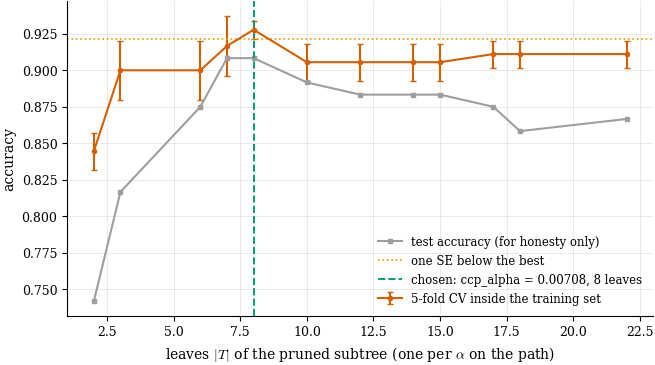

chosen by CV : alpha 0.00708 ->  8 leaves, CV 0.9278 (SE 0.0061), test 0.9083
unpruned     : alpha 0.00000 -> 22 leaves, CV 0.9111, test 0.8667



over 15 train/test splits (mean +- standard error of the mean):
   leaves : pruned   9.73, grown  22.87, difference -13.13 +- 1.63  (8.0 SE from zero)
   test   : pruned 0.8900, grown 0.8889, difference +0.0011 +- 0.0079  (0.1 SE from zero)
   pruning won on 8 splits, tied on 2, lost on 5

So the +0.0417 we saw on the first split was NOT a general
fact: with 180 training points we cannot detect an accuracy gain from pruning.
What we CAN detect, at 8 SE, is the SIZE: the same accuracy from half the leaves.


In [9]:
alphas_cc = DecisionTreeClassifier(random_state=0).cost_complexity_pruning_path(
    Xtr_mn, ytr_mn).ccp_alphas[:-1]            # drop the alpha that collapses to the root
cvm_cc, cvse_cc, leaves_cc, test_cc = [], [], [], []
for a in alphas_cc:
    c_cc = DecisionTreeClassifier(random_state=0, ccp_alpha=a)
    s_cc = cross_val_score(c_cc, Xtr_mn, ytr_mn, cv=cv_mn)
    cvm_cc.append(s_cc.mean())
    cvse_cc.append(s_cc.std() / np.sqrt(5))
    c_cc.fit(Xtr_mn, ytr_mn)
    leaves_cc.append(c_cc.get_n_leaves())
    test_cc.append(c_cc.score(Xte_mn, yte_mn))
cvm_cc, cvse_cc, leaves_cc, test_cc = map(np.array, (cvm_cc, cvse_cc, leaves_cc, test_cc))
keep_cc = np.r_[True, leaves_cc[1:] != leaves_cc[:-1]]          # one row per distinct subtree
cvm_cc, cvse_cc, leaves_cc, test_cc, alphas_cc = (v[keep_cc] for v in
                                                  (cvm_cc, cvse_cc, leaves_cc, test_cc, alphas_cc))
k_cc = int(cvm_cc.argmax())
k1_cc = int(np.max(np.flatnonzero(cvm_cc >= cvm_cc[k_cc] - cvse_cc[k_cc])))   # the 1-SE rule

print(f"{'ccp_alpha':>10s} {'|T|':>4s} {'CV mean':>8s} {'+-SE':>7s} {'test':>7s}")
for i, a in enumerate(alphas_cc):
    mark = "  <- CV best" if i == k_cc else ""
    mark += "  <- 1-SE rule" if i == k1_cc else ""
    print(f"{a:10.6f} {leaves_cc[i]:4d} {cvm_cc[i]:8.4f} {cvse_cc[i]:7.4f} {test_cc[i]:7.4f}{mark}")

fig, ax = plt.subplots(figsize=(6.6, 3.7))
ax.errorbar(leaves_cc, cvm_cc, yerr=cvse_cc, fmt="-o", ms=3, color=C1, capsize=2,
            label="5-fold CV inside the training set")
ax.plot(leaves_cc, test_cc, "-s", ms=3, color=CX, label="test accuracy (for honesty only)")
ax.axhline(cvm_cc[k_cc] - cvse_cc[k_cc], color=CN, ls=":", lw=1.2, label="one SE below the best")
ax.axvline(leaves_cc[k_cc], color=CG, ls="--", lw=1.4,
           label=f"chosen: ccp_alpha = {alphas_cc[k_cc]:.5f}, {leaves_cc[k_cc]} leaves")
ax.set_xlabel(r"leaves $|T|$ of the pruned subtree (one per $\alpha$ on the path)")
ax.set_ylabel("accuracy")
ax.legend(fontsize=8.5, loc="lower right")
plt.show()
print(f"chosen by CV : alpha {alphas_cc[k_cc]:.5f} -> {leaves_cc[k_cc]:2d} leaves, "
      f"CV {cvm_cc[k_cc]:.4f} (SE {cvse_cc[k_cc]:.4f}), test {test_cc[k_cc]:.4f}")
print(f"unpruned     : alpha {alphas_cc[0]:.5f} -> {leaves_cc[0]:2d} leaves, "
      f"CV {cvm_cc[0]:.4f}, test {test_cc[0]:.4f}")

# --- one split proves nothing: repeat the WHOLE procedure on 15 splits -------
rep = []
for seed in range(15):
    Xa, Xb, ya, yb = train_test_split(Xmn, ymn, test_size=0.4, random_state=seed, stratify=ymn)
    cv_s = StratifiedKFold(5, shuffle=True, random_state=seed)
    al_s = DecisionTreeClassifier(random_state=0).cost_complexity_pruning_path(Xa, ya).ccp_alphas[:-1]
    sc_s = [cross_val_score(DecisionTreeClassifier(random_state=0, ccp_alpha=a), Xa, ya,
                            cv=cv_s).mean() for a in al_s]
    pr_s = DecisionTreeClassifier(random_state=0, ccp_alpha=al_s[int(np.argmax(sc_s))]).fit(Xa, ya)
    gr_s = DecisionTreeClassifier(random_state=0).fit(Xa, ya)
    rep.append((pr_s.get_n_leaves(), gr_s.get_n_leaves(), pr_s.score(Xb, yb), gr_s.score(Xb, yb)))
rep = np.array(rep, dtype=float)
d_leaf, d_acc = rep[:, 0] - rep[:, 1], rep[:, 2] - rep[:, 3]

print(f"\nover {len(rep)} train/test splits (mean +- standard error of the mean):")
print(f"   leaves : pruned {rep[:, 0].mean():6.2f}, grown {rep[:, 1].mean():6.2f}, "
      f"difference {d_leaf.mean():+.2f} +- {se_mean(d_leaf):.2f}  "
      f"({abs(d_leaf.mean() / se_mean(d_leaf)):.1f} SE from zero)")
print(f"   test   : pruned {rep[:, 2].mean():.4f}, grown {rep[:, 3].mean():.4f}, "
      f"difference {d_acc.mean():+.4f} +- {se_mean(d_acc):.4f}  "
      f"({abs(d_acc.mean() / se_mean(d_acc)):.1f} SE from zero)")
print(f"   pruning won on {int((d_acc > 0).sum())} splits, tied on {int((d_acc == 0).sum())}, "
      f"lost on {int((d_acc < 0).sum())}")
print(f"\nSo the {test_cc[k_cc] - test_cc[0]:+.4f} we saw on the first split was NOT a general")
print("fact: with 180 training points we cannot detect an accuracy gain from pruning.")
print("What we CAN detect, at 8 SE, is the SIZE: the same accuracy from half the leaves.")

## 8. Feature importance, and what it does not mean

scikit-learn's `feature_importances_` is **MDI**, the mean decrease in impurity: for each feature,
add up $\frac{n_m}{n}\Delta I(m)$ over the nodes that split on it, then normalize so the
importances sum to $1$. On the ten points there are only three internal nodes, so we can add the
numbers up by hand and match `feature_importances_` exactly.

The point of doing it by hand is one warning: **the root feature need not be the most important
one**. "Splits first" and "contributes most" are different questions, and here they have
different answers. MDI has a second, larger problem &mdash; it is computed on the *training* data
with no penalty for the number of thresholds a feature offers, so a continuous noise column can
outrank a real one. That experiment needs many features and a forest to be worth running, so it
lives in notebook&nbsp;09a, next to the permutation importance that fixes it.

feature  node                  (n_m/n) * gain
x1       root, x1 <= 3.5             0.214286
x2       node B, x2 <= 5.5           0.152381
x2       node D, x2 <= 2.5           0.133333

feature      summed  normalized   sklearn
x1         0.214286    0.428571  0.428571
x2         0.285714    0.571429  0.571429

they sum to 0.5000, which is the root impurity 0.5000, and normalize to 3/7 = 0.4286 and 4/7 = 0.5714
max |ours - feature_importances_| = 5.6e-17

The ROOT feature x1 is NOT the most important one: x2 splits twice and earns more.


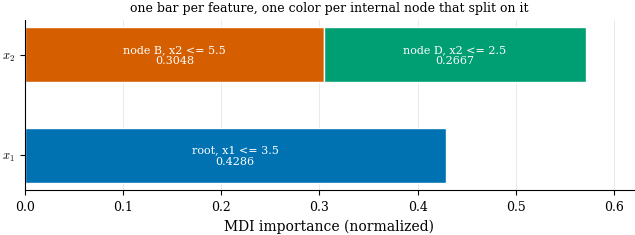

In [10]:
mB_fi = X10[:, 0] > 3.5
mD_fi = mB_fi & (X10[:, 1] <= 5.5)
pieces_fi = {"x1": [("root, x1 <= 3.5", 10 / 10 * gain(X10, y10, 0, 3.5))],
             "x2": [("node B, x2 <= 5.5", 7 / 10 * gain(X10[mB_fi], y10[mB_fi], 1, 5.5)),
                    ("node D, x2 <= 2.5", 3 / 10 * gain(X10[mD_fi], y10[mD_fi], 1, 2.5))]}
total_fi = sum(v for parts in pieces_fi.values() for _, v in parts)

print(f"{'feature':8s} {'node':20s} {'(n_m/n) * gain':>15s}")
for nm, parts in pieces_fi.items():
    for label, v in parts:
        print(f"{nm:8s} {label:20s} {v:15.6f}")
print(f"\n{'feature':8s} {'summed':>10s} {'normalized':>11s} {'sklearn':>9s}")
worst_fi = 0.0
for i, (nm, parts) in enumerate(pieces_fi.items()):
    v = sum(p for _, p in parts)
    worst_fi = max(worst_fi, abs(v / total_fi - tree10.feature_importances_[i]))
    print(f"{nm:8s} {v:10.6f} {v / total_fi:11.6f} {tree10.feature_importances_[i]:9.6f}")
print(f"\nthey sum to {total_fi:.4f}, which is the root impurity {gini(y10):.4f}, and normalize "
      f"to 3/7 = {3/7:.4f} and 4/7 = {4/7:.4f}")
print(f"max |ours - feature_importances_| = {worst_fi:.1e}")
print("\nThe ROOT feature x1 is NOT the most important one: x2 splits twice and earns more.")

node_col = dict(zip([lab for parts in pieces_fi.values() for lab, _ in parts],
                    (C0, C1, CG)))     # one color per INTERNAL NODE, not per feature
fig, ax = plt.subplots(figsize=(6.4, 2.4))
for i, (nm, parts) in enumerate(pieces_fi.items()):
    leftpos = 0.0
    for label, v in parts:
        ax.barh(i, v / total_fi, left=leftpos, color=node_col[label], height=0.55,
                edgecolor="white")
        ax.text(leftpos + v / total_fi / 2, i, f"{label}\n{v / total_fi:.4f}", ha="center",
                va="center", fontsize=8, color="white")
        leftpos += v / total_fi
ax.set_yticks([0, 1], ["$x_1$", "$x_2$"])
ax.set_title("one bar per feature, one color per internal node that split on it", fontsize=9)
ax.set_xlabel("MDI importance (normalized)")
ax.set_xlim(0, 0.62)
ax.grid(axis="y", visible=False)
plt.show()

## 9. Instability &mdash; and the bridge to Session&nbsp;09

Here are the payoff and the price in one place. On the Wisconsin breast-cancer data a depth-3 tree
is a model a clinician can **read**: eight leaves, every path a sentence. Over fifteen train/test
splits its accuracy is also indistinguishable from the sprawling grown tree's, at half the size.

Then we do the honest thing and ask how much of that flow chart is real. A **bootstrap resample**
draws $n$ points from the training set *with replacement* &mdash; a plausible alternative sample from
the same source. We refit the same recipe on 50 of them and watch what the tree says.

The cause of what follows is the `argmax` in the split search: two candidate splits can be
separated by $0.0001$, a tiny change in the data flips which one wins, and **everything below it**
changes discontinuously.

on this split -- depth 3:  8 leaves, test 0.901 | grown: 16 leaves, test 0.906


over 15 splits (mean +- SE) -- depth 3: 7.5 leaves, 0.9224 +- 0.0054 | grown: 16.3 leaves, 0.9259 +- 0.0061
paired difference -0.0035 +- 0.0050 -- half the leaves, and no accuracy difference we can resolve

the largest leaf (234 of 398 training biopsies, 98.7% benign):
   IF worst perimeter <= 106.100 AND worst concave points <= 0.158 AND area error <= 48.975


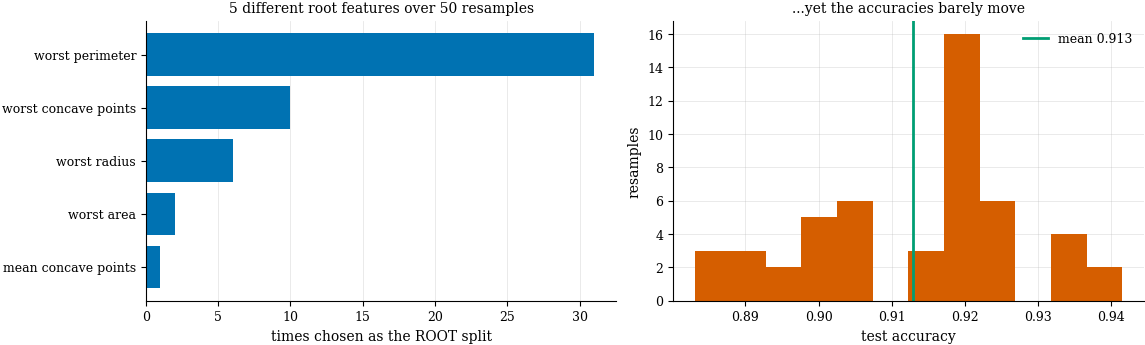

root feature over 50 resamples: {'worst perimeter': 31, 'worst concave points': 10, 'worst radius': 6, 'worst area': 2, 'mean concave points': 1}
even when the root repeats ('worst perimeter', 31 times), its threshold ranges 106.05 to 115.35
test accuracy: mean 0.913, min 0.883, max 0.942

Many DIFFERENT trees, all about EQUALLY good: that is variance, not bias --
and variance is the one thing averaging can remove.


In [11]:
from collections import Counter

bc = load_breast_cancer()
Xtr_bc, Xte_bc, ytr_bc, yte_bc = train_test_split(bc.data, bc.target, test_size=0.3,
                                                  random_state=0, stratify=bc.target)
tree3_bc = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xtr_bc, ytr_bc)
grown_bc = DecisionTreeClassifier(random_state=0).fit(Xtr_bc, ytr_bc)
print(f"on this split -- depth 3: {tree3_bc.get_n_leaves():2d} leaves, test "
      f"{tree3_bc.score(Xte_bc, yte_bc):.3f} | grown: {grown_bc.get_n_leaves():2d} leaves, "
      f"test {grown_bc.score(Xte_bc, yte_bc):.3f}")

rep_bc = []
for seed in range(15):
    Xa, Xb, ya, yb = train_test_split(bc.data, bc.target, test_size=0.3, random_state=seed,
                                      stratify=bc.target)
    a3 = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xa, ya)
    ag = DecisionTreeClassifier(random_state=0).fit(Xa, ya)
    rep_bc.append((a3.get_n_leaves(), ag.get_n_leaves(), a3.score(Xb, yb), ag.score(Xb, yb)))
rep_bc = np.array(rep_bc, dtype=float)
d_bc = rep_bc[:, 2] - rep_bc[:, 3]
print(f"over 15 splits (mean +- SE) -- depth 3: {rep_bc[:, 0].mean():.1f} leaves, "
      f"{rep_bc[:, 2].mean():.4f} +- {se_mean(rep_bc[:, 2]):.4f} | grown: {rep_bc[:, 1].mean():.1f} "
      f"leaves, {rep_bc[:, 3].mean():.4f} +- {se_mean(rep_bc[:, 3]):.4f}")
print(f"paired difference {d_bc.mean():+.4f} +- {se_mean(d_bc):.4f} -- half the leaves, and no "
      f"accuracy difference we can resolve")


def leaf_rule(clf, feature_names, node):
    "the AND of inequalities on the path from the root down to `node`"
    tt, parent = clf.tree_, {}
    for i in range(tt.node_count):
        for child, side in ((tt.children_left[i], "<="), (tt.children_right[i], ">")):
            if child != -1:
                parent[child] = (i, side)
    rule = []
    while node in parent:
        p, side = parent[node]
        rule.append(f"{feature_names[tt.feature[p]]} {side} {tt.threshold[p]:.3f}")
        node = p
    return " AND ".join(reversed(rule))


tb = tree3_bc.tree_
big = max((i for i in range(tb.node_count) if tb.children_left[i] == -1),
          key=lambda i: tb.n_node_samples[i])
print(f"\nthe largest leaf ({tb.n_node_samples[big]} of {len(ytr_bc)} training biopsies, "
      f"{tb.value[big][0].max() * 100:.1f}% {bc.target_names[tb.value[big][0].argmax()]}):")
print("   IF " + leaf_rule(tree3_bc, bc.feature_names, big))

# --- refit the same recipe on 50 bootstrap resamples of the SAME training set ---
rng_bs = np.random.default_rng(0)
roots_bs, thr_bs, accs_bs = [], [], []
for _ in range(50):
    idx = rng_bs.integers(0, len(ytr_bc), len(ytr_bc))
    b = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xtr_bc[idx], ytr_bc[idx])
    roots_bs.append(str(bc.feature_names[b.tree_.feature[0]]))
    thr_bs.append(float(b.tree_.threshold[0]))
    accs_bs.append(b.score(Xte_bc, yte_bc))
counts_bs, accs_bs = Counter(roots_bs), np.array(accs_bs)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.5))
labs, vals = zip(*counts_bs.most_common())
a1.barh(list(labs)[::-1], list(vals)[::-1], color=C0)
a1.set_xlabel("times chosen as the ROOT split")
a1.grid(axis="y", visible=False)
a1.set_title(f"{len(counts_bs)} different root features over 50 resamples", fontsize=10)
a2.hist(accs_bs, bins=12, color=C1)
a2.axvline(accs_bs.mean(), color=CG, lw=2, label=f"mean {accs_bs.mean():.3f}")
a2.set_xlabel("test accuracy")
a2.set_ylabel("resamples")
a2.legend(fontsize=9)
a2.set_title("...yet the accuracies barely move", fontsize=10)
plt.show()

top_bs = counts_bs.most_common(1)[0][0]
same_bs = [v for r, v in zip(roots_bs, thr_bs) if r == top_bs]
print(f"root feature over 50 resamples: {dict(counts_bs.most_common())}")
print(f"even when the root repeats ('{top_bs}', {len(same_bs)} times), its threshold ranges "
      f"{min(same_bs):.2f} to {max(same_bs):.2f}")
print(f"test accuracy: mean {accs_bs.mean():.3f}, min {accs_bs.min():.3f}, "
      f"max {accs_bs.max():.3f}")
print("\nMany DIFFERENT trees, all about EQUALLY good: that is variance, not bias --")
print("and variance is the one thing averaging can remove.")

### The cure, and where it is built

If the trees disagree because each one saw a slightly different sample, then **average them**:
fit $B$ trees on $B$ bootstrap resamples and let them vote. Each tree is as jagged and
overconfident as before; the vote is not. **Notebook&nbsp;09a builds that mechanism** &mdash;
the resamples, the out-of-bag estimate, and the feature randomization that turns bagging into a
random forest &mdash; so this notebook hands it over instead of repeating it.

One measurement does belong here, because it is the bridge: the claim "the vote is better"
needs exactly the treatment section&nbsp;7 gave pruning, so the cell below takes the paired
difference over **fifteen** splits. The rule here is a **hard majority vote** over the twenty
trees' `predict`; notebook&nbsp;09a averages `predict_proba` instead.

In [12]:
# One split proves nothing, here no more than in section 7: repeat over 15 splits and take
# the PAIRED difference. The ensemble rule below is a HARD MAJORITY VOTE over each tree's
# predict(); notebook 09a averages predict_proba instead.
B_bag = 20                                                          # <-- CHANGE ME

gaps_bag = []
for seed in range(15):
    Xa, Xb, ya, yb = train_test_split(Xmn, ymn, test_size=0.4, random_state=seed, stratify=ymn)
    rr = np.random.default_rng(seed)
    V = np.zeros((B_bag, len(yb)))
    for b in range(B_bag):
        idx = rr.integers(0, len(ya), len(ya))                      # a bootstrap resample
        V[b] = DecisionTreeClassifier(random_state=0).fit(Xa[idx], ya[idx]).predict(Xb)
    vote_acc = ((V.mean(0) > 0.5).astype(int) == yb).mean()
    single_acc = DecisionTreeClassifier(random_state=0).fit(Xa, ya).score(Xb, yb)
    gaps_bag.append((vote_acc, single_acc))
gaps_bag = np.array(gaps_bag)
dg = gaps_bag[:, 0] - gaps_bag[:, 1]

print(f"over 15 splits (mean +- SE): the majority vote of {B_bag} bootstrap trees "
      f"{gaps_bag[:, 0].mean():.4f} +- {se_mean(gaps_bag[:, 0]):.4f}, "
      f"one fully grown tree {gaps_bag[:, 1].mean():.4f} +- {se_mean(gaps_bag[:, 1]):.4f}")
print(f"paired difference {dg.mean():+.4f} +- {se_mean(dg):.4f} "
      f"({abs(dg.mean() / se_mean(dg)):.1f} SE from zero); the vote won on {int((dg > 0).sum())} "
      f"splits, tied on {int((dg == 0).sum())}, lost on {int((dg < 0).sum())}")
print("\nUnlike pruning, THIS effect resolves. Averaging leaves the bias alone and cuts the")
print("variance -- which is exactly what section 9 measured too much of. That is Session 09.")

over 15 splits (mean +- SE): the majority vote of 20 bootstrap trees 0.9078 +- 0.0079, one fully grown tree 0.8889 +- 0.0089
paired difference +0.0189 +- 0.0035 (5.4 SE from zero); the vote won on 12 splits, tied on 3, lost on 0

Unlike pruning, THIS effect resolves. Averaging leaves the bias alone and cuts the
variance -- which is exactly what section 9 measured too much of. That is Session 09.


## Recap & exercises

**Recap.**
* A tree carves feature space into **axis-aligned boxes** and predicts one constant per box. On
  the ten points: 4 leaves, thresholds $3.5/5.5/2.5$, 10/10 correct, where a nearly unregularized
  linear model reaches $0.70$.
* **Impurity is the cost of the best constant** in a node. Our three-line `gini()` matched
  `tree_.impurity` to $0$, and the root's information gain was exactly $3/14$.
* A split is scored by the **size-weighted** gain, which is $\ge 0$ because impurity is concave.
  The **error rate is piecewise linear**, so it scored a split that produces a *pure leaf* at
  exactly $0$, against $6/49=0.122449$ for Gini and $0.291692$ for entropy. Grow with Gini or
  entropy.
* Only **$n-1$ thresholds per feature** can matter (18 in all here, two of them worth exactly
  zero), and a tree sees only a feature's **order**: $\log$ and standardization gave the identical
  partition, while a $30^\circ$ rotation needed **6 leaves instead of 4**.
* **Greedy is short-sighted.** On XOR every root split has gain $0$ (largest $|{\Delta I}|$ over
  all 198 candidates: $5.6\times10^{-17}$), so `min_impurity_decrease` stops at one leaf and 50%,
  and even greedy `max_depth=2` reaches only $0.51$ on the 200-point version &mdash; while growing
  out and judging later reaches $1.00$ every time. Grow first, prune after.
* **Tree size is the complexity knob**, and training accuracy is monotone in it (checked), so it
  cannot choose. On the moons split, CV peaked at **8 leaves**.
* **Regression trees** are the same algorithm with SSE and the mean: the eight apartments split at
  `area <= 4.5` for a gain of **128.00**, and at `area = 100` the depth-1 stump still predicts
  **11.50** while the depth-3 tree of &sect;6 predicts **13.00** &mdash; each one repeating its
  right-most leaf. A tree cannot extrapolate.
* **Cost-complexity pruning** searches a short list: on the ten points the breakpoints were
  exactly $0,\ \tfrac{2}{15},\ \tfrac{16}{105},\ \tfrac{3}{14}$, each rederived by hand as a
  weakest link $g(m)$.
* **What pruning buys, measured over 15 splits:** less than half the leaves (a difference of
  $-13.1\pm1.6$ leaves, $8.0$ SE from zero) and an accuracy difference we **cannot** resolve
  ($+0.0011\pm0.0079$). The $+0.0417$ on the first split was noise. Prune for size and readability,
  not for a promised accuracy gain at this sample size.
* **MDI is not "how useful is this feature".** By hand, the root feature was *not* the most
  important one ($3/7$ against $4/7$). Notebook&nbsp;09a shows the bigger failure and its fix.
* **Instability is the deal-breaker.** 50 bootstrap resamples of one training set produced
  **5 different root features** while test accuracy stayed between $0.883$ and $0.942$. That is
  variance &mdash; and a **hard majority vote** of 20 bootstrap trees improved the test accuracy
  by $+0.0189\pm0.0035$ over 15 splits (5.4 SE, better on 12 splits and never worse), an effect
  that *does* resolve. Notebook&nbsp;09a builds that vote.

**Exercises.**
1. In &sect;2, switch every `gini` to `entropy` and refit with `criterion="entropy"`. Do the three
   splits of the ten points change? Does anything change except the printed impurities?
2. In &sect;3, add a third feature equal to $x_1$ plus $10^{-6}$ of noise. Which feature does the
   root choose, and what does that do to the importances in &sect;8?
3. In &sect;4, replace `xor_cloud`'s shared offsets by four independent draws. Is the largest root
   gain still $10^{-17}$, and does `min_impurity_decrease=0.01` still stop at the root? What does
   that say about how fragile the exact zero is?
4. In &sect;6, add a ninth apartment with area $9$ and rent $20$. How far does the depth-1 split
   move, and what does the tree now predict at `area = 100`?
5. In &sect;7, re-run the repeat loop with `n_samples=2000` instead of 300. Does the accuracy
   gain from pruning become resolvable? At what training size?
6. **Write it yourself.** Implement the weakest-link algorithm: grow the full tree, and while more
   than one leaf remains, compute $g(m)=\bigl(R(m)-R(T_m)\bigr)/(|T_m|-1)$ for every internal
   node, record the smallest, and collapse that node. Your recorded sequence of $\alpha$ values
   should equal `tree10.cost_complexity_pruning_path(X10, y10).ccp_alphas` on the ten points, then
   `DecisionTreeClassifier(random_state=0).fit(Xtr_mn, ytr_mn)`'s path on the moons data. (Use the
   `risk()` helper from &sect;7 and `tree_.children_left` / `children_right` to walk the tree.)

*Next session:* **ensemble methods** &mdash; bagging, random forests and boosting, all built on the
unstable trees we just measured.